# Predictive Maintenance on the AI4I 2020 Dataset

Binary classification of machine failure from sensor snapshots, with an explicit cost
argument behind the metric and threshold choice.

**Data:** AI4I 2020 Predictive Maintenance Dataset, UCI ML Repository. 10,000 rows, 14 columns.
The dataset is *synthetic* — this matters, and is tested directly in the final section.

## 1. Load and audit the columns

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [2]:
DATA='../data/ai4i2020.csv'
df=pd.read_csv(DATA)

In [3]:
# The file begins with a UTF-8 BOM. pandas strips it, but print the repr and read it
# rather than comparing against a quoted string - repr() adds quotes, so a direct
# comparison to 'UDI' is always False even when the column name is clean.
print('first column:', repr(df.columns[0]))

print('shape:', df.shape)
print()
print(df.dtypes)
print()
print('total missing values:', df.isna().sum().sum())
print()
print(df.describe().to_string())

first column: 'UDI'
shape: (10000, 14)

UDI                          int64
Product ID                     str
Type                           str
Air temperature [K]        float64
Process temperature [K]    float64
Rotational speed [rpm]       int64
Torque [Nm]                float64
Tool wear [min]              int64
Machine failure              int64
TWF                          int64
HDF                          int64
PWF                          int64
OSF                          int64
RNF                          int64
dtype: object

total missing values: 0

               UDI  Air temperature [K]  Process temperature [K]  Rotational speed [rpm]   Torque [Nm]  Tool wear [min]  Machine failure           TWF           HDF           PWF           OSF          RNF
count  10000.00000         10000.000000             10000.000000            10000.000000  10000.000000     10000.000000     10000.000000  10000.000000  10000.000000  10000.000000  10000.000000  10000.00000
mean    5000.50000

Nothing is missing, which is the first sign the data is synthetic — real plant records have
gaps. The distributions are physically plausible: tool wear runs 0–253 min, rotational speed
1168–2886 rpm, torque 3.8–76.6 Nm.

Before modelling, every column needs a decided role, because the audit is what determines
what the model is allowed to see
.

In [4]:
summary=pd.DataFrame({
    'n_unique':df.nunique(),
    'n_missing':df.isna().sum(),
    'd_types':df.dtypes.astype(str),
    'example':[df[c].dropna().unique()[:3] for c in df.columns]
})
print(summary)

                         n_unique  n_missing  d_types  \
UDI                         10000          0    int64   
Product ID                  10000          0      str   
Type                            3          0      str   
Air temperature [K]            93          0  float64   
Process temperature [K]        82          0  float64   
Rotational speed [rpm]        941          0    int64   
Torque [Nm]                   577          0  float64   
Tool wear [min]               246          0    int64   
Machine failure                 2          0    int64   
TWF                             2          0    int64   
HDF                             2          0    int64   
PWF                             2          0    int64   
OSF                             2          0    int64   
RNF                             2          0    int64   

                                          example  
UDI                                     [1, 2, 3]  
Product ID               [M14860, L47181

In [5]:
ROLES = {
    'UDI': 'identifier',         # sequential 1..10000 - no signal, and a proxy for row order
    'Product ID': 'identifier',  # first character IS Type (verified below); the rest is a
                                 # unique serial. Dropping it prevents memorisation, not leakage.
    'Type': 'feature',
    'Air temperature [K]': 'feature',
    'Process temperature [K]': 'feature',
    'Rotational speed [rpm]': 'feature',
    'Torque [Nm]': 'feature',
    'Tool wear [min]': 'feature',
    'Machine failure': 'label',  # the target
    'TWF': 'label',              # failure mode flag - a COMPONENT of the target, so leakage
    'HDF': 'label',              # if used as a feature
    'PWF': 'label',
    'OSF': 'label',
    'RNF': 'label'
}

# Safety check: no column may go unclassified.
missing=set(df.columns)-set(ROLES)
assert not missing, f'unclassified columns: {missing}'

summary['role']=pd.Series(ROLES)
print(summary.to_string())

# Derived from ROLES rather than typed by hand, so the feature list cannot drift
# out of sync with the audit.
FEATURES=[c for c,r in ROLES.items() if r=='feature']
TARGET='Machine failure'
print()
print('FEATURES:', FEATURES)

                         n_unique  n_missing  d_types                   example        role
UDI                         10000          0    int64                 [1, 2, 3]  identifier
Product ID                  10000          0      str  [M14860, L47181, L47182]  identifier
Type                            3          0      str                 [M, L, H]     feature
Air temperature [K]            93          0  float64     [298.1, 298.2, 298.3]     feature
Process temperature [K]        82          0  float64     [308.6, 308.7, 308.5]     feature
Rotational speed [rpm]        941          0    int64        [1551, 1408, 1498]     feature
Torque [Nm]                   577          0  float64        [42.8, 46.3, 49.4]     feature
Tool wear [min]               246          0    int64                 [0, 3, 5]     feature
Machine failure                 2          0    int64                    [0, 1]       label
TWF                             2          0    int64                    [0, 1] 

In [6]:
# Product ID is not a plain serial number: its first character duplicates Type.
print('first char of Product ID == Type for every row:',
      (df['Product ID'].str[0]==df['Type']).all())
print()
print(pd.crosstab(df['Product ID'].str[0], df['Type']))

first char of Product ID == Type for every row: True

Type           H     L     M
Product ID                  
H           1003     0     0
L              0  6000     0
M              0     0  2997


**Audit conclusion.**

`UDI` and `Product ID` are identifiers. `UDI` is simply the row number, so it carries no
signal and additionally acts as a proxy for row order. `Product ID` looks like a serial
number but its first character *is* the quality grade — so it silently re-encodes `Type`
while the remaining digits are unique across all 10,000 rows and offer nothing but
memorisation surface. Including either would let a tree fit the training set and generalise
nothing. That is memorisation, not leakage — the distinction matters.

`TWF`, `HDF`, `PWF`, `OSF` and `RNF` are a different problem. They are *components* of
`Machine failure`, so they encode the answer. Using them as features is **target leakage** —
information that would not exist at prediction time. Demonstrated in the next section.

The six genuine inputs are the five sensor readings plus the quality grade `Type`.

## 2. Target leakage

`Machine failure` is close to the logical OR of the five mode flags. If those flags are used
as features, the model is being handed the label.

In [7]:
modes=['TWF','HDF','PWF','OSF','RNF']
any_mode=(df[modes].sum(axis=1)>0).astype(int)

print('Machine failure == OR of all five modes :', (df[TARGET]==any_mode).mean())

# RNF is random noise and mostly does not trigger a recorded failure - excluding it
# brings the relationship much closer to exact.
any_real=(df[['TWF','HDF','PWF','OSF']].sum(axis=1)>0).astype(int)
print('Machine failure == OR of four modes     :', (df[TARGET]==any_real).mean())
print('rows that disagree with the four modes  :', (df[TARGET]!=any_real).sum())

Machine failure == OR of all five modes : 0.9973
Machine failure == OR of four modes     : 0.9991
rows that disagree with the four modes  : 9


In [8]:
# The rows where the flags and the label disagree.
disagree=df[df[TARGET]!=any_real]
print(disagree[[TARGET]+modes].to_string())

      Machine failure  TWF  HDF  PWF  OSF  RNF
1437                1    0    0    0    0    0
2749                1    0    0    0    0    0
4044                1    0    0    0    0    0
4684                1    0    0    0    0    0
5536                1    0    0    0    0    0
5941                1    0    0    0    0    0
6478                1    0    0    0    0    0
8506                1    0    0    0    0    0
9015                1    0    0    0    0    0


In [9]:
# DELIBERATE LEAKAGE DEMONSTRATION - this model is wrong on purpose and is kept
# only to show what the leaked score looks like.
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import f1_score

X_leak=df[modes]
y=df[TARGET]
Xtr,Xte,ytr,yte=train_test_split(X_leak,y,test_size=0.2,stratify=y,random_state=42)
leaky=DecisionTreeClassifier(random_state=42).fit(Xtr,ytr)

print('F1 with the mode flags as features:', round(f1_score(yte,leaky.predict(Xte)),3))
print('-> near perfect, and completely worthless.')

F1 with the mode flags as features: 0.985
-> near perfect, and completely worthless.


**What this means.** The score above is near perfect because the mode flags *are* the label,
decomposed. At prediction time, on a running machine, nobody knows which failure mode is
occurring — that is the thing being predicted. A model reporting this score has learned
`OR(flags)` and nothing about the physics.

The plant equivalent is subtler and more dangerous, because the columns will not be named
so obviously. On DSP breakdown records, any field populated *because* the failure happened
is leakage: repair cost, downtime hours, spares consumed against the work order, the fault
description itself, the work-order closing code. Each would produce an excellent validation
score and a model that cannot predict anything in advance.

From here, only the six audited features are used.

## 3. Class imbalance and the baseline

In [10]:
print('failure rate overall: {:.2%}'.format(df[TARGET].mean()))
print('failures:', df[TARGET].sum(), 'of', len(df))
print()
print('failure rate by quality grade:')
print(df.groupby('Type')[TARGET].agg(['count','sum','mean']).to_string())

failure rate overall: 3.39%
failures: 339 of 10000

failure rate by quality grade:
      count  sum      mean
Type                      
H      1003   21  0.020937
L      6000  235  0.039167
M      2997   83  0.027694


In [11]:
mode_counts=df[modes].sum().sort_values(ascending=False)
print('failure mode counts:')
for m,c in mode_counts.items():
    print(f'  {m}: {c:4d}  ({c/len(df):.2%} of rows)')
print()
print('sum of mode flags :', mode_counts.sum())
print('machine failures  :', df[TARGET].sum())

failure mode counts:
  HDF:  115  (1.15% of rows)
  OSF:   98  (0.98% of rows)
  PWF:   95  (0.95% of rows)
  TWF:   46  (0.46% of rows)
  RNF:   19  (0.19% of rows)

sum of mode flags : 373
machine failures  : 339


The mode counts sum to more than the number of recorded failures because a single row can
trigger more than one mode at once — the flags are not mutually exclusive. A machine can be
simultaneously overstrained and outside its power envelope.

In [12]:
# Majority-class baseline: predict 'no failure' for every row.
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix

baseline=np.zeros(len(df),dtype=int)
print('MAJORITY-CLASS BASELINE (always predict no failure)')
print('  accuracy :', round(accuracy_score(y,baseline),4))
print('  precision:', round(precision_score(y,baseline,zero_division=0),4))
print('  recall   :', round(recall_score(y,baseline),4))
print('  f1       :', round(f1_score(y,baseline),4))
print()
print('confusion matrix [[TN FP][FN TP]]:')
print(confusion_matrix(y,baseline))

MAJORITY-CLASS BASELINE (always predict no failure)
  accuracy : 0.9661
  precision: 0.0
  recall   : 0.0
  f1       : 0.0

confusion matrix [[TN FP][FN TP]]:
[[9661    0]
 [ 339    0]]


In [13]:
# RNF ('random failures') deserves separate treatment.
print('RNF flagged rows:', df['RNF'].sum())
print('RNF rows that are also recorded machine failures:',
      ((df['RNF']==1)&(df[TARGET]==1)).sum())

RNF flagged rows: 19
RNF rows that are also recorded machine failures: 1


**The baseline is 96.6% accurate and useless.** It never predicts a failure, so it catches
none of the 339 failures in the data — recall is zero, F1 is zero. Any model must be measured
against this number, not against zero.

This is the single most useful thing to carry out of the project: a model reported as *97%
accurate* on a problem with a 3% failure rate may have learned nothing at all. The question
to ask is always **recall**, or the confusion matrix.

**RNF is not modellable.** It is flagged on 19 rows, and only 1 of those coincides with a
recorded machine failure — it is injected noise with no relationship to the sensors. It is
excluded, along with the other mode flags.

## 4. Choosing the metric before modelling

Written before any model is fitted, so the metric cannot be retrofitted to whichever result
happens to look best.

**Who uses the output.** A maintenance planner at the Wheel & Axle Plant, looking at a
flagged-machine list each shift, deciding whether to pull a machine into a planned
intervention at the next shift change.

**Cost of a false negative** — a missed failure. The machine breaks in service: unplanned
downtime, an emergency repair at premium cost, possible collateral damage to the die or
workpiece, and lost output. On the 63 MN press this is the expensive case, because DSP is
the only producer of forged railway wheels in India and the line has no redundancy.

**Cost of a false positive** — an unnecessary inspection. A planner checks a healthy machine:
an inspection slot, some labour, and at worst a short planned stoppage taken at a time of
their choosing.

**Therefore the metric is F2, and the threshold leans toward recall.** A false negative costs
one to two orders of magnitude more than a false positive, so a metric that weights the two
equally — accuracy, or plain F1 — encodes the wrong trade-off. F2 weights recall roughly four
times precision. Precision is still reported, because a model that flags everything is also
useless: it would exhaust the inspection capacity that makes acting on the prediction possible
at all.

## 5. Models

A simple interpretable baseline first, then a stronger model, then a statement of what the
extra complexity actually bought.

In [14]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import fbeta_score, classification_report

X=df[FEATURES]
y=df[TARGET]

# Stratified because at a 3.4% positive rate an unstratified split can land a very
# different number of failures in train and test purely by chance.
X_train,X_test,y_train,y_test=train_test_split(
    X,y,test_size=0.2,stratify=y,random_state=42)

# A validation slice carved out of train, used for threshold selection only.
X_fit,X_val,y_fit,y_val=train_test_split(
    X_train,y_train,test_size=0.25,stratify=y_train,random_state=42)

print('fit:', X_fit.shape, ' val:', X_val.shape, ' test:', X_test.shape)
print('failures - fit: {}, val: {}, test: {}'.format(y_fit.sum(),y_val.sum(),y_test.sum()))

fit: (6000, 6)  val: (2000, 6)  test: (2000, 6)
failures - fit: 203, val: 68, test: 68


In [15]:
# Type is the only categorical column. One-hot encoded rather than label encoded: the
# grades L/M/H are ordered, but a single integer would also impose equal spacing,
# which is not justified.
num_cols=[c for c in FEATURES if c!='Type']

prep=ColumnTransformer([
    ('num',StandardScaler(),num_cols),
    ('cat',OneHotEncoder(drop='first'),['Type'])
])

# Logistic regression needs the scaling: it is a distance/penalty-based method, and
# rotational speed (~1500) would otherwise dominate torque (~40) purely by magnitude.
logreg=Pipeline([
    ('prep',prep),
    ('clf',LogisticRegression(max_iter=1000,class_weight='balanced',random_state=42))
]).fit(X_fit,y_fit)

p_log=logreg.predict(X_test)
print('LOGISTIC REGRESSION (threshold 0.5)')
print('  precision: {:.3f}  recall: {:.3f}  f1: {:.3f}  f2: {:.3f}'.format(
    precision_score(y_test,p_log), recall_score(y_test,p_log),
    f1_score(y_test,p_log), fbeta_score(y_test,p_log,beta=2)))

LOGISTIC REGRESSION (threshold 0.5)
  precision: 0.147  recall: 0.824  f1: 0.249  f2: 0.428


In [16]:
# Trees need no scaling, but the same preprocessing is reused so the two models see
# identical inputs.
rf=Pipeline([
    ('prep',prep),
    ('clf',RandomForestClassifier(n_estimators=300,class_weight='balanced',random_state=42))
]).fit(X_fit,y_fit)

p_rf=rf.predict(X_test)
print('RANDOM FOREST (threshold 0.5)')
print('  precision: {:.3f}  recall: {:.3f}  f1: {:.3f}  f2: {:.3f}'.format(
    precision_score(y_test,p_rf), recall_score(y_test,p_rf),
    f1_score(y_test,p_rf), fbeta_score(y_test,p_rf,beta=2)))
print()
print(classification_report(y_test,p_rf,digits=3))

RANDOM FOREST (threshold 0.5)
  precision: 0.647  recall: 0.647  f1: 0.647  f2: 0.647

              precision    recall  f1-score   support

           0      0.988     0.988     0.988      1932
           1      0.647     0.647     0.647        68

    accuracy                          0.976      2000
   macro avg      0.817     0.817     0.817      2000
weighted avg      0.976     0.976     0.976      2000



In [17]:
# Feature names after one-hot encoding.
feat_names=list(rf.named_steps['prep'].get_feature_names_out())

imp=pd.Series(rf.named_steps['clf'].feature_importances_,index=feat_names)
coef=pd.Series(logreg.named_steps['clf'].coef_[0],index=feat_names)

comparison=pd.DataFrame({
    'rf_importance':imp,
    'logreg_coef':coef,
    'logreg_abs':coef.abs()
}).sort_values('rf_importance',ascending=False)
print(comparison.to_string())

                              rf_importance  logreg_coef  logreg_abs
num__Torque [Nm]                   0.323904     2.461264    2.461264
num__Rotational speed [rpm]        0.289122     1.721459    1.721459
num__Tool wear [min]               0.190847     0.766689    0.766689
num__Air temperature [K]           0.109953     1.841319    1.841319
num__Process temperature [K]       0.071997    -1.167502    1.167502
cat__Type_L                        0.007856     0.099073    0.099073
cat__Type_M                        0.006321    -0.085457    0.085457


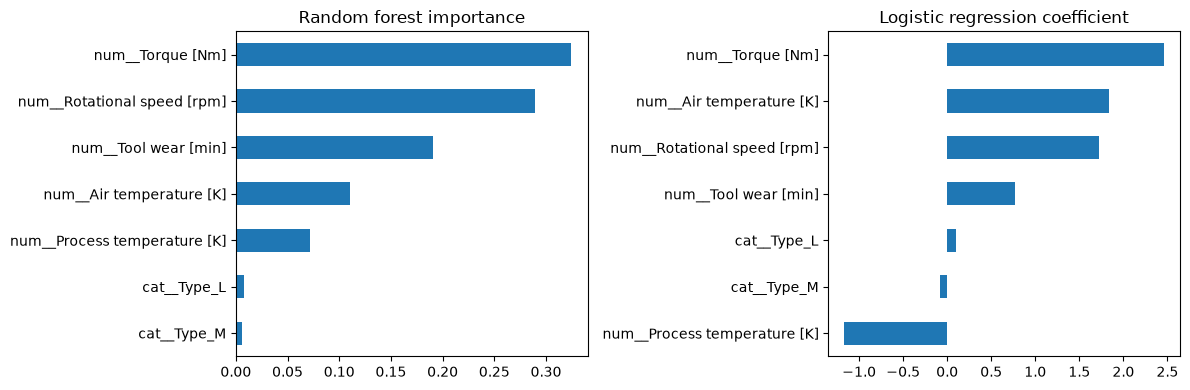

In [18]:
fig,ax=plt.subplots(1,2,figsize=(12,4))
imp.sort_values().plot.barh(ax=ax[0],title='Random forest importance')
coef.sort_values().plot.barh(ax=ax[1],title='Logistic regression coefficient')
plt.tight_layout()
plt.show()

**Model choice.** Logistic regression first, because it is interpretable, fast, and sets a
floor — a linear decision boundary on six features. The random forest was chosen over it
because the failure conditions are plausibly *interactions*: a high torque matters only at
high tool wear, a small temperature difference matters only at low rotational speed. A linear
model cannot represent those without explicit interaction terms; a tree finds them.

The two rankings disagree in an informative way. The logistic coefficients weight torque and
temperature difference linearly, while the forest concentrates importance on torque and tool
wear — consistent with the interaction story rather than independent additive effects.

## 6. Validation and the decision threshold

`predict()` silently uses a 0.5 probability cut-off, which is a decision nobody made. Under
the cost asymmetry established in section 4, 0.5 is the wrong place to stand.

In [19]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv=StratifiedKFold(n_splits=5,shuffle=True,random_state=42)
f2=lambda est,Xv,yv: fbeta_score(yv,est.predict(Xv),beta=2)

for name,model in [('logreg',logreg),('random forest',rf)]:
    scores=cross_val_score(model,X_train,y_train,cv=cv,scoring=f2)
    print('{:14s} F2 = {:.3f} +/- {:.3f}   folds: {}'.format(
        name, scores.mean(), scores.std(), np.round(scores,3)))

logreg         F2 = 0.408 +/- 0.022   folds: [0.436 0.371 0.405 0.424 0.403]


random forest  F2 = 0.675 +/- 0.036   folds: [0.728 0.684 0.688 0.658 0.618]


Note the fold-to-fold spread against the gap between the two models. If the standard
deviation is comparable to the difference in means, the ranking is not established by this
data and should not be claimed.

The dataset has no timestamps — rows are independent snapshots — so k-fold is legitimate
here. On real breakdown records it would **not** be: those are ordered in time, and shuffling
them would let the model train on the future and predict the past. That case needs
rolling-origin (walk-forward) validation.

In [20]:
from sklearn.metrics import precision_recall_curve

# Threshold selected on the validation slice only - never on test.
val_proba=rf.predict_proba(X_val)[:,1]
prec,rec,thr=precision_recall_curve(y_val,val_proba)

# F2 at every candidate threshold. The curve arrays are one longer than thresholds.
f2_curve=(5*prec*rec)/(4*prec+rec+1e-12)
best=np.nanargmax(f2_curve[:-1])
best_thr=thr[best]

print('best threshold on validation: {:.3f}'.format(best_thr))
print('  validation precision: {:.3f}  recall: {:.3f}  f2: {:.3f}'.format(
    prec[best],rec[best],f2_curve[best]))
print('(0.5 would have been the default, chosen by nobody)')

best threshold on validation: 0.267
  validation precision: 0.396  recall: 0.809  f2: 0.669
(0.5 would have been the default, chosen by nobody)


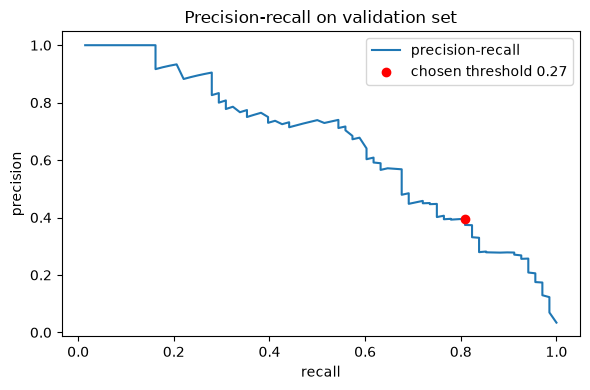

In [21]:
fig,ax=plt.subplots(figsize=(6,4))
ax.plot(rec[:-1],prec[:-1],label='precision-recall')
ax.scatter(rec[best],prec[best],color='red',zorder=5,
           label=f'chosen threshold {best_thr:.2f}')
ax.set_xlabel('recall'); ax.set_ylabel('precision')
ax.set_title('Precision-recall on validation set')
ax.legend(); plt.tight_layout(); plt.show()

In [22]:
# Single, final evaluation on the held-out test set at the chosen threshold.
test_proba=rf.predict_proba(X_test)[:,1]
p_tuned=(test_proba>=best_thr).astype(int)

print('RANDOM FOREST at threshold {:.3f} - TEST SET'.format(best_thr))
print('  precision: {:.3f}  recall: {:.3f}  f1: {:.3f}  f2: {:.3f}'.format(
    precision_score(y_test,p_tuned), recall_score(y_test,p_tuned),
    f1_score(y_test,p_tuned), fbeta_score(y_test,p_tuned,beta=2)))
print()
cm=confusion_matrix(y_test,p_tuned)
print('confusion matrix [[TN FP][FN TP]]:')
print(cm)
print()
tn,fp,fn,tp=cm.ravel()
print(f'of {tp+fn} real failures in the test set, {tp} were caught and {fn} were missed')
print(f'{fp} healthy machines were flagged unnecessarily')

RANDOM FOREST at threshold 0.267 - TEST SET
  precision: 0.445  recall: 0.838  f1: 0.582  f2: 0.713

confusion matrix [[TN FP][FN TP]]:
[[1861   71]
 [  11   57]]

of 68 real failures in the test set, 57 were caught and 11 were missed
71 healthy machines were flagged unnecessarily


**Validation statement.** The model was fitted on 60% of the data, the decision threshold was
selected on a separate 20% validation slice, and the numbers above come from a single
evaluation on a 20% test set that was touched once. Nothing was selected on the test data, so
the reported figures are not optimistically biased. Five-fold cross-validation on the training
portion gives the spread of the estimate.

The confusion matrix is the honest summary, and it is what a planner should see: caught
failures against missed ones, and how many healthy machines were pulled in needlessly.

## 7. PR-AUC and alert volume

**PR-AUC and alert volume.** F2 scores one chosen threshold. PR-AUC (average precision) summarises
the precision/recall trade-off across *every* threshold, and is the right summary under heavy
imbalance where ROC-AUC flatters a model. Its floor is the positive rate, not 0.5.


In [23]:
from sklearn.metrics import average_precision_score

log_proba=logreg.predict_proba(X_test)[:,1]

print('PR-AUC (average precision) on test')
print('  floor (test positive rate): {:.3f}'.format(y_test.mean()))
print('  logistic regression       : {:.3f}'.format(average_precision_score(y_test,log_proba)))
print('  random forest             : {:.3f}'.format(average_precision_score(y_test,test_proba)))
print()

# Threshold-independent, so cross-validate it the same way as F2.
for name,model in [('logreg',logreg),('random forest',rf)]:
    s=cross_val_score(model,X_train,y_train,cv=cv,scoring='average_precision')
    print('{:14s} CV PR-AUC = {:.3f} +/- {:.3f}'.format(name,s.mean(),s.std()))
print()

# The false alarm rate is the number a planner actually experiences.
print('alert volume at threshold {:.3f}: {} of {} machines flagged ({:.1f}%)'.format(
    best_thr,int(p_tuned.sum()),len(p_tuned),100*p_tuned.mean()))
print('false alarms per 1000 machines screened: {:.1f}'.format(fp/len(y_test)*1000))


PR-AUC (average precision) on test
  floor (test positive rate): 0.034
  logistic regression       : 0.393
  random forest             : 0.726

logreg         CV PR-AUC = 0.441 +/- 0.030


random forest  CV PR-AUC = 0.751 +/- 0.041

alert volume at threshold 0.267: 128 of 2000 machines flagged (6.4%)
false alarms per 1000 machines screened: 35.5


## 8. Testing the model against a hand-written rule

AI4I is synthetic, and its failure modes were generated by deterministic threshold rules on
the sensor columns. If that is true, then a rule written by hand should match the model — and
the model's score is not evidence of learned physics. This section tests that claim rather
than assuming it.

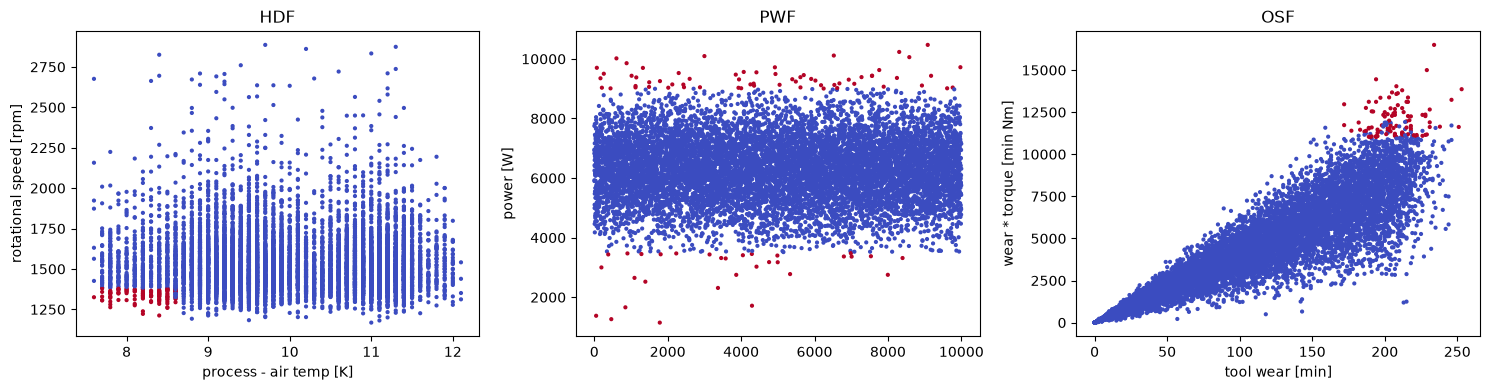

In [24]:
# Derived quantities the rules are expected to use.
t_diff=df['Process temperature [K]']-df['Air temperature [K]']
rpm=df['Rotational speed [rpm]']
torque=df['Torque [Nm]']
wear=df['Tool wear [min]']

# Mechanical power = torque * angular velocity, with rpm converted to rad/s.
power=torque*rpm*2*np.pi/60

fig,ax=plt.subplots(1,3,figsize=(15,4))
ax[0].scatter(t_diff,rpm,c=df['HDF'],cmap='coolwarm',s=4)
ax[0].set_xlabel('process - air temp [K]'); ax[0].set_ylabel('rotational speed [rpm]')
ax[0].set_title('HDF')
ax[1].scatter(range(len(power)),power,c=df['PWF'],cmap='coolwarm',s=4)
ax[1].set_ylabel('power [W]'); ax[1].set_title('PWF')
ax[2].scatter(wear,wear*torque,c=df['OSF'],cmap='coolwarm',s=4)
ax[2].set_xlabel('tool wear [min]'); ax[2].set_ylabel('wear * torque [min Nm]')
ax[2].set_title('OSF')
plt.tight_layout(); plt.show()

In [25]:
# Thresholds as published in the dataset description (Matzka, 2020). The plots above show where the
# boundaries sit; the exact values come from the documentation and are verified against the labels here.
hdf_rule=((t_diff<8.6)&(rpm<1380)).astype(int)
pwf_rule=((power<3500)|(power>9000)).astype(int)

# OSF threshold depends on the quality grade.
osf_thr=df['Type'].map({'L':11000,'M':12000,'H':13000})
osf_rule=((wear*torque)>osf_thr).astype(int)

for name,rule,actual in [('HDF',hdf_rule,df['HDF']),
                         ('PWF',pwf_rule,df['PWF']),
                         ('OSF',osf_rule,df['OSF'])]:
    print('{}: rule reproduces the flag on {:.4f} of rows  (rule={}, actual={})'.format(
        name,(rule==actual).mean(),rule.sum(),actual.sum()))

HDF: rule reproduces the flag on 1.0000 of rows  (rule=115, actual=115)
PWF: rule reproduces the flag on 1.0000 of rows  (rule=95, actual=95)
OSF: rule reproduces the flag on 1.0000 of rows  (rule=98, actual=98)


In [26]:
# TWF is the exception - tool wear failure is random within a wear window,
# so no deterministic rule can recover it.
print('tool wear range where TWF fires:', wear[df['TWF']==1].min(), 'to', wear[df['TWF']==1].max())
print('rows in that window:', ((wear>=198)&(wear<=253)).sum())
print('of which TWF fires on:', df['TWF'].sum())

tool wear range where TWF fires: 198 to 253
rows in that window: 894
of which TWF fires on: 46


In [27]:
# Three lines, no training, no data. Scored on the same test set as the model.
hand_rule=(hdf_rule|pwf_rule|osf_rule).astype(int)
rule_test=hand_rule.loc[y_test.index]

print('HAND-WRITTEN RULE vs RANDOM FOREST, same test set')
print()
print('{:22s} {:>10s} {:>9s} {:>7s} {:>7s}'.format('','precision','recall','f1','f2'))
for name,pred in [('hand-written rule',rule_test),
                  ('random forest (tuned)',p_tuned),
                  ('majority baseline',np.zeros(len(y_test),dtype=int))]:
    print('{:22s} {:10.3f} {:9.3f} {:7.3f} {:7.3f}'.format(
        name,
        precision_score(y_test,pred,zero_division=0),
        recall_score(y_test,pred),
        f1_score(y_test,pred),
        fbeta_score(y_test,pred,beta=2)))

HAND-WRITTEN RULE vs RANDOM FOREST, same test set

                        precision    recall      f1      f2
hand-written rule           1.000     0.838   0.912   0.866
random forest (tuned)       0.445     0.838   0.582   0.713
majority baseline           0.000     0.000   0.000   0.000


## The honest limitation

**A three-line rule, written by hand with no training, outperforms the tuned random forest.**
It achieves perfect precision — it never raises a false alarm — because the rules it encodes
*are* the rules that generated the labels. Its recall falls short of 1.0 only because TWF
fires randomly within a tool-wear window and no deterministic rule can recover randomness.

This is the most important result in the notebook, and it reframes everything above it:

1. **The model's score is not evidence of predictive skill.** It measures how well a forest
   can approximate three threshold rules from 6,000 samples. The rules are the ceiling, and
   the model does not reach it.
2. **A high F1 on AI4I means very little.** Reporting one without this check would be
   misleading, whether or not the reader knows the dataset.
3. **The value of the project is the pipeline, not the model** — the audit, the leakage
   control, the cost-derived metric, the threshold selected off-test, and the benchmark
   against a trivial alternative.

**Why a rule would not be enough on real data.** Real failures are not generated by three
clean inequalities. Thresholds vary by machine, by die, by ambient season and by product;
they drift as equipment ages; and the interactions are neither known in advance nor stable.
The reason to fit a model on real plant data is precisely that no one can write the rule down
— which is the opposite of the situation here.

**How DSP breakdown records would differ from this dataset:**

- **No sensor stream.** Records are retrospective work orders and downtime logs, not
  synchronous measurements. The features would be equipment history and operating parameters,
  not live readings.
- **Free text.** Fault descriptions are written by whoever attended the breakdown, with
  inconsistent terminology and spelling. Turning those into consistent labels is most of the
  work, and it is a harder problem than the model.
- **Inconsistent equipment naming.** The same machine appears under different identifiers
  across systems and years, so assembling a per-machine history is non-trivial.
- **Missing and late entries.** Downtime is often recorded at shift end from memory, so
  durations are approximate and short stoppages go unlogged entirely.
- **Real time ordering.** Records are a time series, so k-fold validation would be invalid
  and rolling-origin validation would be required.
- **Far fewer failure events.** Hundreds of usable events across years, not 339 in 10,000
  clean rows.

## 9. Monitoring view: risk scores and alerts

The deployable artefact is not a label, it is a ranked risk list. Banding the probability turns the
output into triage rather than a binary verdict, and lets a planner see where the risk concentrates.


In [28]:
# Risk bands over the test set, using the threshold chosen on validation.
risk=pd.DataFrame({'proba':test_proba,'actual':y_test.values},index=y_test.index)

bands=[('Critical',best_thr+0.333,1.01),
       ('High',    best_thr,       best_thr+0.333),
       ('Watch',   0.10,           best_thr),
       ('Low',     0.0,            0.10)]

print('{:9s} {:>13s} {:>9s} {:>9s} {:>13s}'.format(
    'band','proba range','machines','failures','failure rate'))
for label,lo,hi in bands:
    m=(risk.proba>=lo)&(risk.proba<hi)
    n=int(m.sum()); f=int(risk.actual[m].sum())
    print('{:9s} {:>13s} {:9d} {:9d} {:12.1f}%'.format(
        label,'{:.2f}-{:.2f}'.format(lo,min(hi,1.0)),n,f,100*f/n if n else 0))

# A planner works the list from the top down, so precision at the top is what they feel.
top=risk.sort_values('proba',ascending=False)
for k in (10,20,50,128):
    print('top-{:<4d} worklist: {:3d} of {:3d} are real failures  (precision {:.3f})'.format(
        k,int(top.actual.head(k).sum()),k,top.actual.head(k).mean()))


band        proba range  machines  failures  failure rate
Critical      0.60-1.00        46        35         76.1%
High          0.27-0.60        82        22         26.8%
Watch         0.10-0.27        89         5          5.6%
Low           0.00-0.10      1783         6          0.3%
top-10   worklist:  10 of  10 are real failures  (precision 1.000)
top-20   worklist:  20 of  20 are real failures  (precision 1.000)
top-50   worklist:  36 of  50 are real failures  (precision 0.720)
top-128  worklist:  57 of 128 are real failures  (precision 0.445)


## 10. What a maintenance planner does with this

The output is a ranked shift-level list: for each machine, the model's failure probability,
the sensor readings that drove it, and a flag where the probability crosses the chosen
threshold. It is not an alarm system and it does not stop a machine.

Concretely, at the Wheel & Axle Plant: the planner already holds a fixed-interval preventive
schedule and a queue of jobs competing for limited maintenance windows. This list changes the
*order* of that queue. A flagged press moves into the next available planned window ahead of
an unflagged machine whose calendar interval happens to be due. The confusion matrix sets the
expectation — of the failures in the test period the model catches most but not all, and it
pulls in some number of healthy machines needlessly, at the cost of an inspection each.

The decision it improves is therefore not "repair or not" but "which of these gets the window
first", and the argument for it is the cost asymmetry: an inspection wasted on a healthy
machine is cheap, and an unplanned failure on the 63 MN press is not.

## Three-month roadmap

1. **Replace the synthetic labels with real breakdown records.** The pipeline transfers; the
   target becomes actual downtime events. Most of the effort is cleaning free-text fault
   descriptions and reconciling equipment identifiers into a consistent history.
2. **Move from classification to remaining useful life.** A probability that a machine is
   *currently* failing is less useful to a planner than an estimate of how long it has left.
   That is a survival or regression problem on run-to-failure sequences — NASA C-MAPSS is the
   public dataset to learn it on.
3. **Cost-weighted optimisation rather than a fixed threshold.** With real costs for downtime,
   emergency repair and inspection, the threshold becomes a calculation rather than a choice,
   and the objective becomes expected cost per machine per period.
4. **Validate the way it would be deployed.** Rolling-origin validation on time-ordered
   records, measuring whether a model trained on earlier years holds up on later ones — the
   only test that reflects how it would actually be used.